**Initialize**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

col = ['time', 'long', 'x', 'y', 'z']
r_k = pd.read_csv('KAMOOALEWA.aei', sep='\s+', skiprows=4, names=col)
r_f = pd.read_csv('2023FW13.aei', sep='\s+', skiprows=4, names=col)
r_e = pd.read_csv('EARTHMOO.aei', sep='\s+', skiprows=4, names=col)

**ICRF**

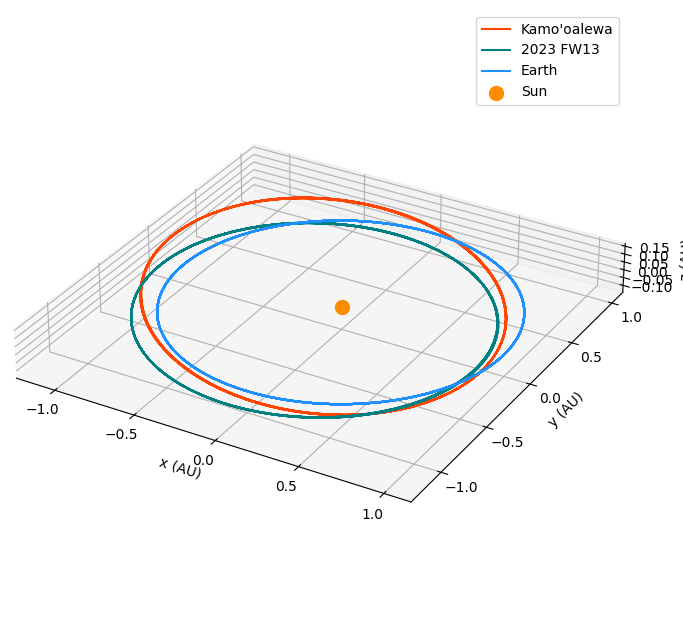

In [2]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(r_k['x'], r_k['y'], r_k['z'], label='Kamo\'oalewa', color='orangered')
ax.plot(r_f['x'], r_f['y'], r_f['z'], label='2023 FW13', color='teal')
ax.plot(r_e['x'], r_e['y'], r_e['z'], label='Earth', color='dodgerblue')
ax.scatter([0], [0], [0], color='darkorange', s=100, label='Sun')

ax.set_aspect('equal')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_zlabel('z (AU)')
ax.legend()
ax.grid(True)
plt.show()

**Earth-centric coordinates**

In [3]:
theta = np.arctan2(r_e['y'], r_e['x'])

x_rot_k = r_k['x'] * np.cos(theta) + r_k['y'] * np.sin(theta) - (r_e['x'] * np.cos(theta) + r_e['y'] * np.sin(theta))
y_rot_k = -r_k['x'] * np.sin(theta) + r_k['y'] * np.cos(theta) - (-r_e['x'] * np.sin(theta) + r_e['y'] * np.cos(theta))
z_rot_k = r_k['z'] - r_e['z']

x_rot_f = r_f['x'] * np.cos(theta) + r_f['y'] * np.sin(theta) - (r_e['x'] * np.cos(theta) + r_e['y'] * np.sin(theta))
y_rot_f = -r_f['x'] * np.sin(theta) + r_f['y'] * np.cos(theta) - (-r_e['x'] * np.sin(theta) + r_e['y'] * np.cos(theta))
z_rot_f = r_f['z'] - r_e['z']

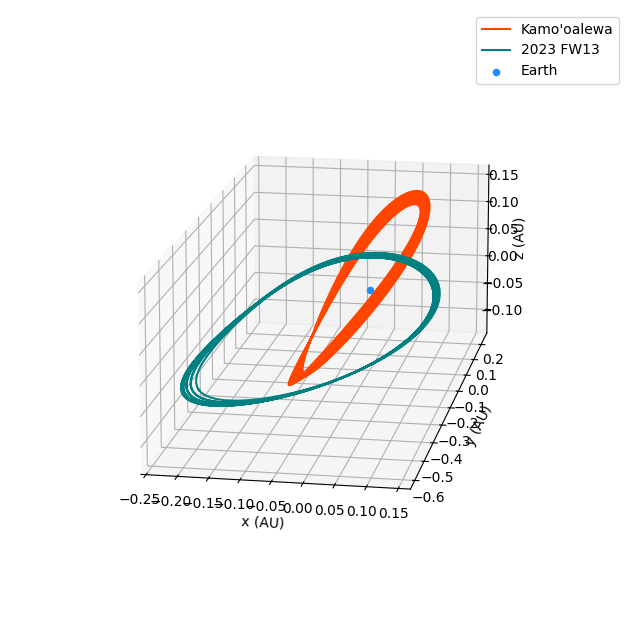

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_rot_k, y_rot_k, z_rot_k, label='Kamo\'oalewa', color='orangered')
ax.plot(x_rot_f, y_rot_f, z_rot_f, label='2023 FW13', color='teal')
ax.scatter(0, 0, 0, label='Earth', color='dodgerblue')

ax.view_init(elev=15, azim=-80)
ax.set_aspect('equal')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_zlabel('z (AU)')
ax.legend()
ax.grid(True)
plt.show()

**HORIZONS Data**

In [16]:
from astroquery.jplhorizons import Horizons
import numpy as np

from astropy.time import Time
import numpy as np
from astroquery.jplhorizons import Horizons

start_jd = 2458400.5
duration_yrs = 1
stop_jd = start_jd + (duration_yrs * 365.25)

start_iso = Time(start_jd, format='jd').iso.split()[0]
stop_iso = Time(stop_jd, format='jd').iso.split()[0]

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '5d'
}

obj_k = Horizons(id='469219', location='10', epochs=epochs)
vec_k = obj_k.vectors(refplane='ecliptic')

obj_e = Horizons(id='399', location='10', epochs=epochs)
vec_e = obj_e.vectors(refplane='ecliptic')

x_real_k, y_real_k = np.array(vec_k['x']), np.array(vec_k['y'])
x_real_e, y_real_e = np.array(vec_e['x']), np.array(vec_e['y'])

theta_real = np.arctan2(y_real_e, x_real_e)

x_rot_k_real = x_real_k * np.cos(theta_real) + y_real_k * np.sin(theta_real) - (x_real_e * np.cos(theta_real) + y_real_e * np.sin(theta_real))
y_rot_k_real = -x_real_k * np.sin(theta_real) + y_real_k * np.cos(theta_real)

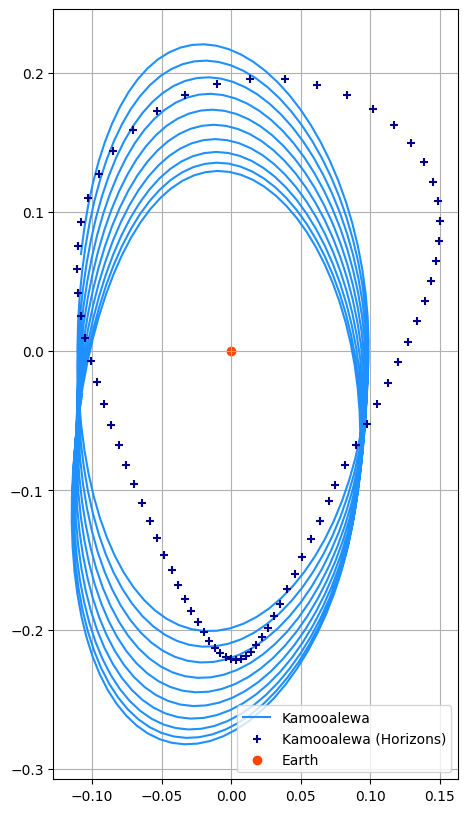

In [17]:
plt.figure(figsize=(10, 10))

plt.plot(x_rot_k, y_rot_k, label='Kamooalewa', color='dodgerblue')
plt.scatter(x_rot_k_real, y_rot_k_real, label='Kamooalewa (Horizons)', color='darkblue', marker='+', s=30, zorder=5)
plt.scatter(0, 0, label='Earth', color='orangered')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()